- 합성곱 층 가중치, 특성 맵 시각화
- 신경망이 이미지에서 어떤 것을 학습하는지 알기

In [2]:
import keras
model = keras.models.load_model('best-cnn-model.keras')

In [3]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

### 가중치 시각화

In [4]:
# 첫 번째 합성곱 층 가중치 조사
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape) # 가중치, 절편

(3, 3, 1, 32) (32,)


In [5]:
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())

-0.023085594 0.24494837


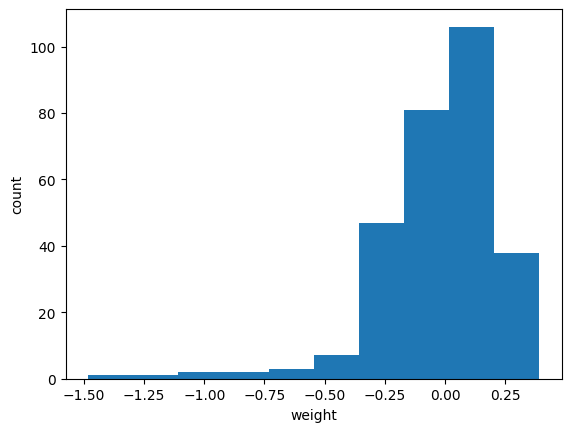

In [6]:
# 가중치 분포 히스토그램으로 표현
import matplotlib.pyplot as plt
plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

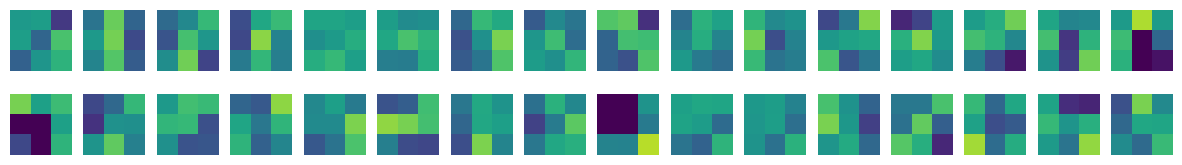

In [7]:
# 32개 커널 16개씩 두 출에 출력
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:, :, 0, i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

In [9]:
# 훈련 안 한 모델 만들어서 비교해보기
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Input(shape=(28, 28, 1)))
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

# 첫 번째 Conv2D층 가중치 저장
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())

(3, 3, 1, 32)
0.005067141 0.08017518


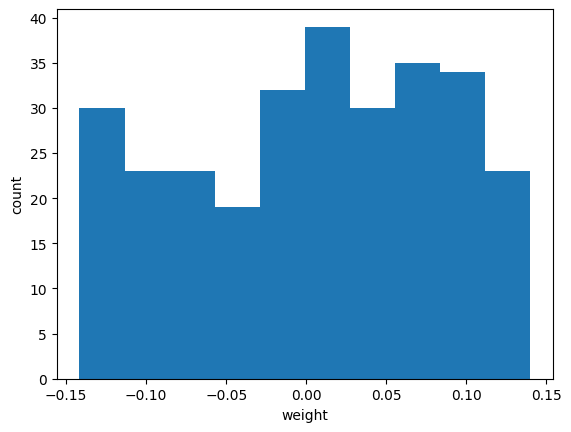

In [ ]:
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

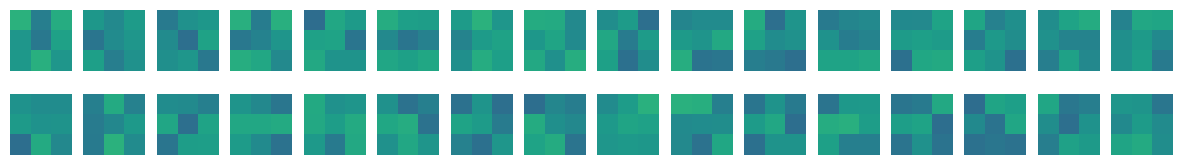

In [11]:
# 32개 커널 16개씩 두 출에 출력
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_training_weights[:, :, 0, i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

- 아무 것도 학습시키지 않은 합성곱 층은 무작위 수로 설정되어 있음

---

### 합성곱 층에서 출력된 특성 맵 그려 보기
- 입력 이미지를 신경망 층이 어떻게 바라보는지 알 수 있음

In [ ]:
# 케라스 함수형 API 사용 예시
# Dense 층 2개로 이루어진 완전 연결 신경망
inputs = keras.Input(shape=(784, ))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')
hidden = dense1(inputs) # 객체 호출
outputs = dense2(hidden)
func_model = keras.Model(inputs, outputs) # input과 output을 Model 클래스로 연결

In [15]:
print(model.inputs)

conv_acti = keras.Model(model.inputs[0], model.layers[0].output) # 입력과 첫 번째 Conv2D를 통과한 출력 사용한 모델
# 이 모델을 가지고 predict 하면 첫 번째 Conv2D의 출력만 반환함

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer>]


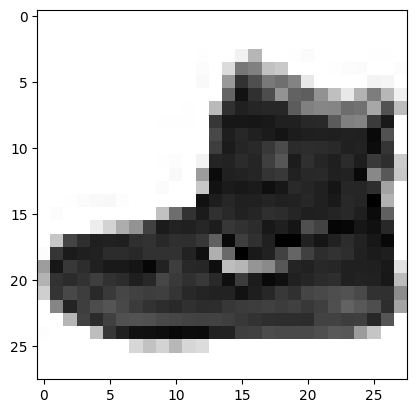

In [16]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
(1, 28, 28, 32)


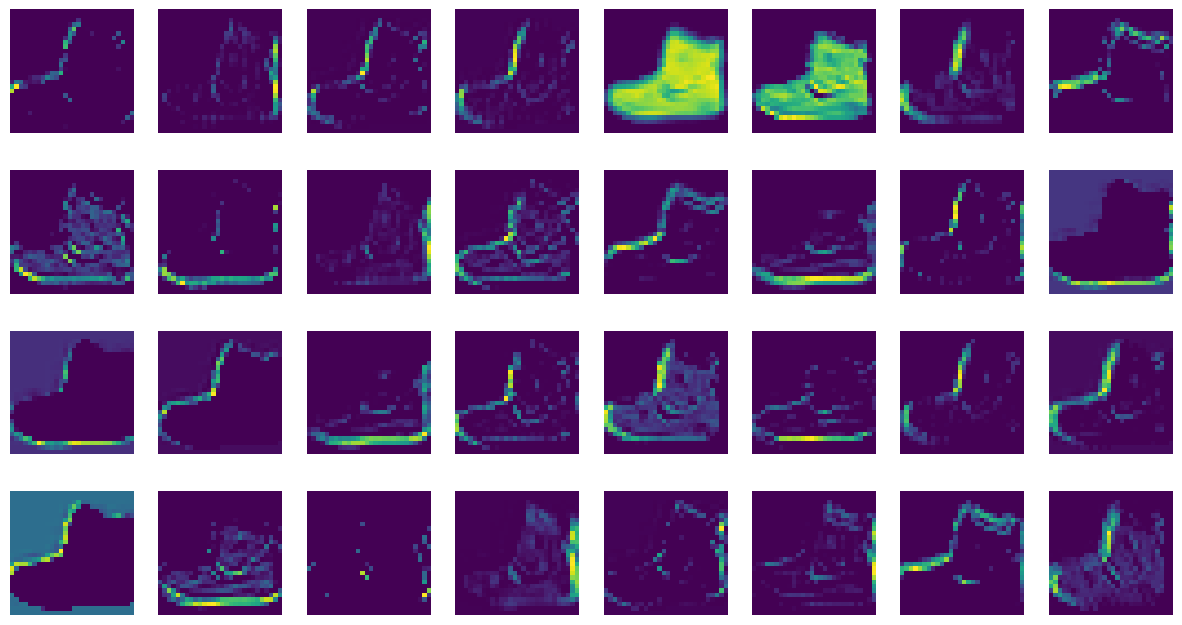

In [19]:
# 위의 신발 이미지를 conv_acti에 주입해 Conv2D 층이 만드는 특성을 시각화해보기
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv_acti.predict(ankle_boot)
print(feature_maps.shape)

# 32개의 특성 맵을 4개의 행으로 나누어 그림
fig, axs = plt.subplots(4, 8, figsize=(15, 8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0, :, :, i*8 + j])
        axs[i, j].axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
(1, 14, 14, 64)


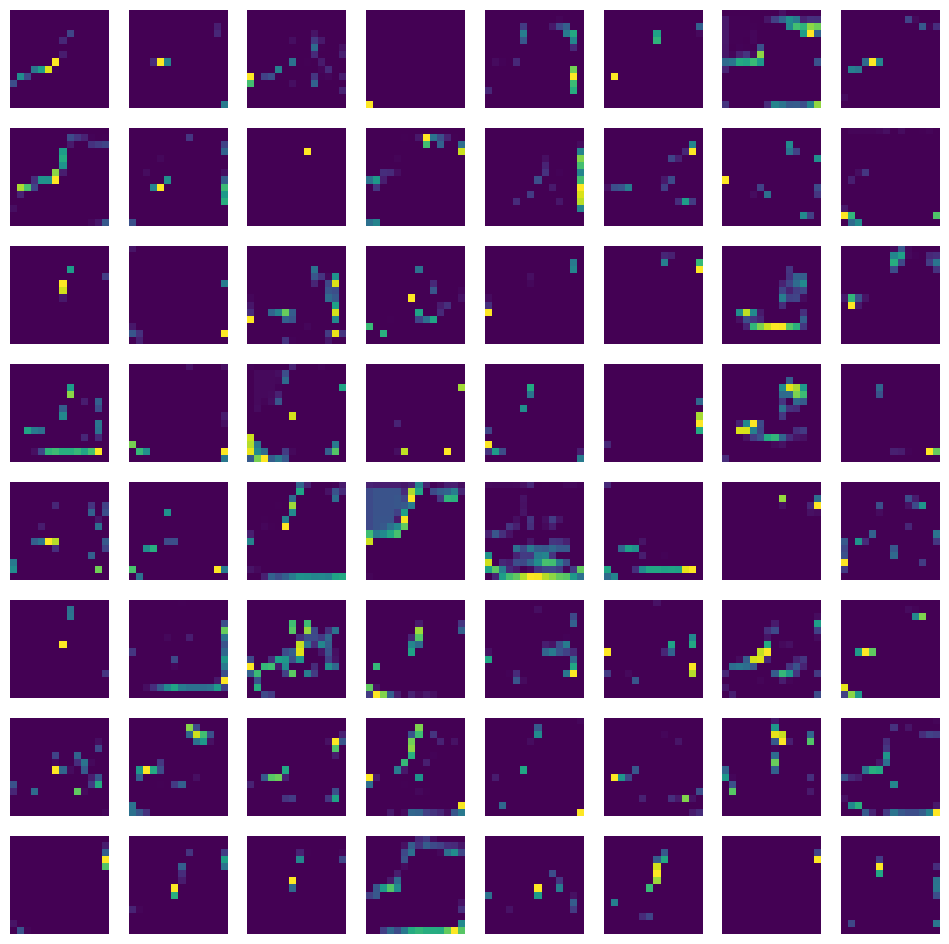

In [20]:
# 두 번째 합성곱 층이 만든 특성맵 확인
conv2_acti = keras.Model(model.inputs[0], model.layers[2].output)
feature_maps = conv2_acti.predict(ankle_boot)
print(feature_maps.shape)

fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0, :, :, i*8 + j])
        axs[i, j].axis('off')
plt.show()

- 조금 알아보기 힘든 결과가 나옴
- 이는 다음과 같은 과정으로 만들어짐
  - 두 번째 합성곱 층의 첫 번째 필터가 앞서 출력된 32개의 특성 맵과 곱해짐 -> 두 번째 층의 첫 번째 특성 맵
  - ...
- 이런 현상은 합성곱 층을 많이 쌓을 수록 심해짐
  - 바꾸어 생각하면 앞부분 합성곱 층은 이미지의 **시각적인 정보 학습**
  - 뒤쪽 합성곱 층은 앞쪽에서 감지한 **시각적인 정보 바탕으로 추상적인 정보 학습**